# Data Cleaning with the Titanic Dataset

This notebook focuses on exploring and cleaning the [Titanic dataset](https://www.kaggle.com/competitions/titanic/data) from the Kaggle competition.

The goal is to identify missing values, inspect potential outliers, evaluate the available variables, and prepare the dataset for further processing.

Although the dataset was originally provided for a machine learning competition, this notebook focuses specifically on the data cleaning stage. Therefore, no predictive model will be developed here.

The cleaning decisions are made with the potential use of the dataset in subsequent modeling steps in mind.

## Variables
- Survival: Survival status (0 = No, 1 = Yes)
- Pclass: Ticket class (1 = 1st, 2 = 2nd, 3 = 3rd)
- Sex: Gender
- Age: Age in years
- SibSp: Number of siblings/spouses aboard the Titanic
- Parch: Number of parents/children aboard the Titanic
- Ticket: Ticket number
- Fare: Passenger fare
- Cabin: Cabin number
- Embarked: Port of embarkation (C = Cherbourg, Q = Queenstown, S = Southampton)

In [ ]:
# Import libraries
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

## Initial Data Exploration

### Data overview

This section provides an initial overview of the dataset, including its structure, data types, descriptive statistics, unique values, and missing values.

The purpose of this initial exploration is to identify potential data quality issues that may need to be addressed during the cleaning stage.

In [ ]:
# Define data path
titanic_path = Path("data") / "train.csv"
print(titanic_path)

data\train.csv


In [ ]:
# Load the titanic dataset
titanic = pd.read_csv(titanic_path)

In [ ]:
# Display the first three rows
titanic.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


### Data structure and types

Before addressing specific data quality issues, it is useful to understand the dataset's dimensions, data types, and basic descriptive statistics.

In [43]:
print('Titanic shape:', titanic.shape)

print('\nTitanic info:')
titanic.info()

print('\nDescriptive statistics:')
titanic.describe()

Titanic shape: (891, 12)

Titanic info:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB

Descriptive statistics:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Unique Values and Missing Values

Checking the number of unique values helps identify the cardinality of each variable, while checking for missing values highlights columns that require further investigation.

At this stage, the main missing values are found in `Age`, `Cabin`, and `Embarked`.

In [44]:
print("Unique values:")
display(titanic.nunique())

print("\nMissing values:")
display(titanic.isnull().sum()) 

Unique values:


PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64


Missing values:


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## Data Cleaning

Based on the initial exploration, the main data quality issues identified are missing values and potential outliers.

The following steps investigate these issues individually and apply appropriate cleaning decisions while preserving as much useful information as possible.

### Verifying missing values

#### -  Missing values in `Embarked`

In [ ]:
# Inspect the records with missing values in Embarked
titanic[titanic.Embarked.isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


According to the historical information available for these two passengers, both embarked at Southampton (`S`).

Therefore, instead of removing these records or using a statistical imputation method, the missing values can be filled with `S`.

In [ ]:
# Update the missing Embarked values to 'S' (Southampton)
titanic.loc[titanic.Embarked.isnull(), 'Embarked'] = 'S'

#### Missing values in `Age`

There are 177 missing values in the `Age` column.

Since age is a numerical variable and removing these records would result in a significant loss of information, I will investigate possible ways to estimate the missing values.

In [ ]:
# Verify null values in Age
titanic[titanic.Age.isnull()].shape

(177, 12)

In [ ]:
# Display descriptive statistics for the Age column
titanic.Age.describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

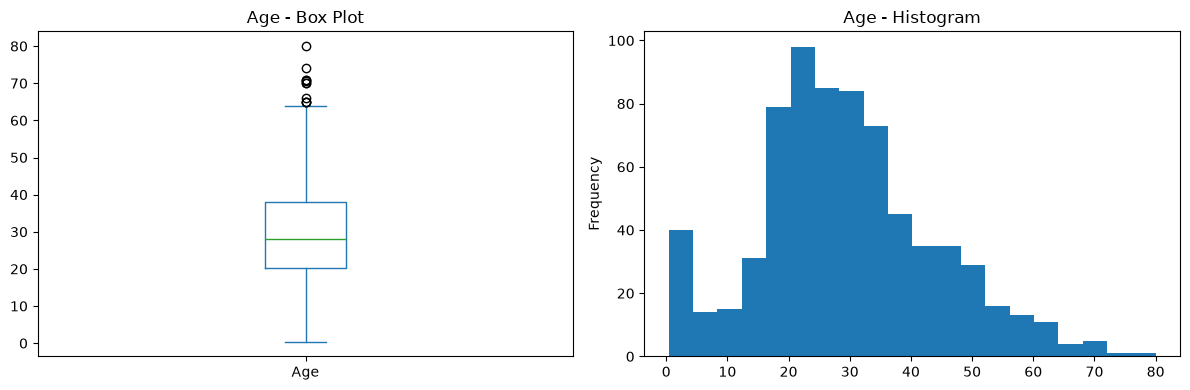

In [ ]:
# Visualize the distribution of the Age column
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

titanic["Age"].plot.box(ax=axes[0])
axes[0].set_title("Age Distribution — Box Plot")

titanic["Age"].plot.hist(bins=20, ax=axes[1])
axes[1].set_title("Age Distribution — Histogram")

plt.tight_layout()
plt.show()

The median age is 28 years, but using the overall median for all missing values may overlook differences between passenger groups.

Because `Pclass` and `Sex` describe relevant characteristics of the passengers, I will compare approaches based on these variables before choosing how to fill the missing ages.

In [ ]:
# Median age value
titanic.Age.median()

np.float64(28.0)

In [ ]:
# Median age per some of the groups
print("Median Age by Class:")
display(titanic.groupby('Pclass')['Age'].median())

print("\nMedian Age by Class and Sex:")
display(titanic.groupby(['Pclass', 'Sex'])['Age'].median()) 

Median Age by Class:


Pclass
1    37.0
2    29.0
3    24.0
Name: Age, dtype: float64


Median Age by Class and Sex:


Pclass  Sex   
1       female    35.0
        male      40.0
2       female    28.0
        male      30.0
3       female    21.5
        male      25.0
Name: Age, dtype: float64

Since the median Age grouped by class and sex provide more nuanced values of Age, we'll use those values to replace the null values of the people with missing ages

### Comparing approaches for imputing `Age`

To compare different ways of applying the same imputation logic, I will temporarily create additional columns.

The first approach calculates the median age for each combination of `Pclass` and `Sex` and uses it to fill the missing values.

In [ ]:
# Create a new age column with the median age per class and sex
titanic['Age_Check1'] = titanic.groupby(['Pclass', 'Sex'])['Age'].transform('median')

titanic.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_Check1
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,25.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,35.0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,21.5


The same result can also be obtained more directly with `fillna()`, applying the group-specific median only where `Age` is missing.

In [ ]:
# Apply directly only to the missing values with fillna
titanic['Age_Check2'] = titanic.Age.fillna(titanic.groupby(['Pclass', 'Sex'])['Age'].transform('median'))

titanic.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_Check1,Age_Check2
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,25.0,22.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,35.0,38.0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,21.5,26.0


The second approach allows the missing values to be filled directly in the original `Age` column, without creating an additional permanent column.

For this reason, I will keep this approach and remove the temporary comparison columns.

In [59]:
# Instead of creating a new column, we can also update the Age column directly with the median age per class and sex for the missing values
titanic['Age'] = titanic.Age.fillna(titanic.groupby(['Pclass', 'Sex'])['Age'].transform('median'))

titanic.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_Check1,Age_Check2
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,25.0,22.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,35.0,38.0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,21.5,26.0


In [ ]:
# Remove temporary columns used to compare the imputation approaches
titanic = titanic.drop(['Age_Check1', 'Age_Check2'], axis=1)

In [ ]:
# Verify that all missing Age values have been filled
titanic.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

The `Age` column no longer contains missing values.

#### Missing values in `Cabin`

The `Cabin` column contains a large number of missing values. Before deciding how to handle them, I will inspect the available cabin values and their frequency.

In [62]:
# Verifying cabin information
titanic.Cabin.value_counts()

Cabin
G6             4
C23 C25 C27    4
B96 B98        4
F33            3
E101           3
              ..
E17            1
A24            1
C50            1
B42            1
C148           1
Name: count, Length: 147, dtype: int64

The `Cabin` variable has a high proportion of missing values and would require additional processing to make it consistently usable.

Since the cabin information is not part of the variables I intend to retain for the subsequent processing of this dataset, I will remove this column rather than attempt to impute the missing values.

In [ ]:
# Remove Cabin because it will not be retained for subsequent processing
titanic = titanic.drop('Cabin', axis=1)

### Checking for potential outliers

After handling the missing values, I will check the numerical variables for potential outliers.

The `Fare` variable is particularly relevant to investigate because its maximum value is considerably higher than its median.

In [65]:
# Describe statistics
titanic.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.112424,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.304424,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,21.500000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,26.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,36.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


<Axes: >

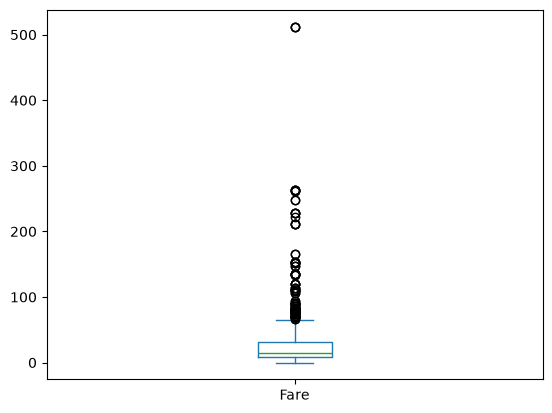

In [66]:
# Verifying fare
titanic.Fare.plot.box()

The boxplot indicates the presence of high values in the `Fare` variable.

However, an extreme value should not automatically be considered an error. I will inspect the records containing the maximum fare to determine whether these values are valid observations.

In [67]:
# Verifying Fare outlier
titanic[titanic.Fare == titanic.Fare.max()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,C
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,C
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,C


The maximum fare is `512.3292`. After checking the corresponding passenger records and the available historical information, there is no indication that this value is an error.

The same fare is associated with multiple passengers sharing the same ticket, which also helps explain why the value appears more than once.

Therefore, I will keep these observations rather than treating them as erroneous outliers.

In a subsequent modeling stage, the impact of extreme values on the chosen algorithm could be evaluated separately.

## Final Dataset Review

After handling the identified missing values and reviewing potential outliers, I will perform a final review of the dataset.

This step checks the remaining variables, their cardinality, and the final structure of the dataset before it is considered ready for subsequent processing.

In [68]:
titanic.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S


In [ ]:
# Check the cardinality
titanic.nunique()

PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             89
SibSp            7
Parch            7
Ticket         681
Fare           248
Embarked         3
dtype: int64

The cardinality of the remaining variables provides a final check of the dataset structure before removing variables that are not intended to be used in subsequent processing.

### Removing identifier-like variables

`PassengerId` is an identifier assigned to each passenger and does not represent a passenger characteristic.

`Ticket` identifies the ticket associated with each passenger and has high cardinality. In its current form, it is not being used as a feature for the subsequent processing of this dataset.

Therefore, both columns will be removed.

In [ ]:
# Remove identifier-like columns that will not be used for subsequent processing
titanic = titanic.drop(['PassengerId', 'Ticket'], axis=1)

titanic.head(3)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S


In [ ]:
# Display the final dataset structure
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    str    
 3   Sex       891 non-null    str    
 4   Age       891 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Fare      891 non-null    float64
 8   Embarked  891 non-null    str    
dtypes: float64(2), int64(4), str(3)
memory usage: 62.8 KB


The cleaned dataset now contains 891 records and 9 variables.

At this point, the missing values identified during the initial exploration have been addressed, the `Cabin` column has been removed, potential extreme values in `Fare` have been investigated, and identifier-like columns that will not be used in subsequent processing have been removed.

The resulting dataset is therefore ready for the next stages of data processing, such as feature transformation and model preparation.

## Conclusion

The main objective of this notebook was to clean and prepare the Titanic dataset for subsequent data processing.

During the exploration and cleaning stages, I:
- investigated the dataset structure and data types;
- identified and handled missing values in `Embarked` and `Age`;
- removed the `Cabin` column due to its high number of missing values and its exclusion from the variables retained for further processing;
- investigated potential outliers in `Fare` and kept valid extreme values;
- removed identifier-like columns that were not intended to be used in subsequent processing.

The resulting dataset contains 891 records and 9 variables, with no missing values in the retained columns.

The dataset is now ready for subsequent preprocessing and modeling steps, which are outside the scope of this notebook.